In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.feature_selection import SelectKBest, f_classif


import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../PHASE-1/Data/heart_cleaned.csv")

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [3]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
selector = SelectKBest(score_func=f_classif, k=10)  # choose top 10 features
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", list(selected_features))

Selected Features: ['Age', 'RestingBP', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


c:\Users\Vanshika\Desktop\Projects\PBL\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Vanshika\Desktop\Projects\PBL\venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [7]:
params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=5)
grid.fit(X_train_selected, y_train)

model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}


In [8]:
y_pred = model.predict(X_test_selected)
y_prob = model.predict_proba(X_test_selected)[:, 1]

In [9]:
print("\n--- Model Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


--- Model Performance ---
Accuracy: 0.8152173913043478
Precision: 0.8842105263157894
Recall: 0.7850467289719626
F1 Score: 0.8316831683168316
ROC AUC: 0.9086054132783105


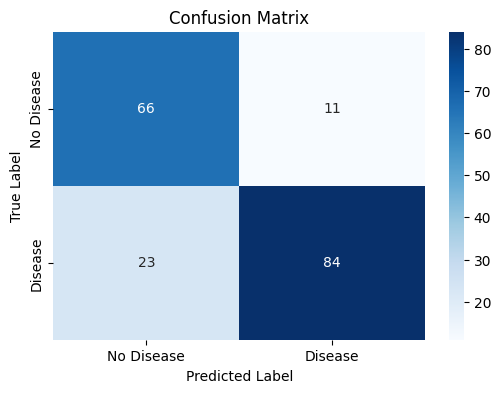

In [10]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

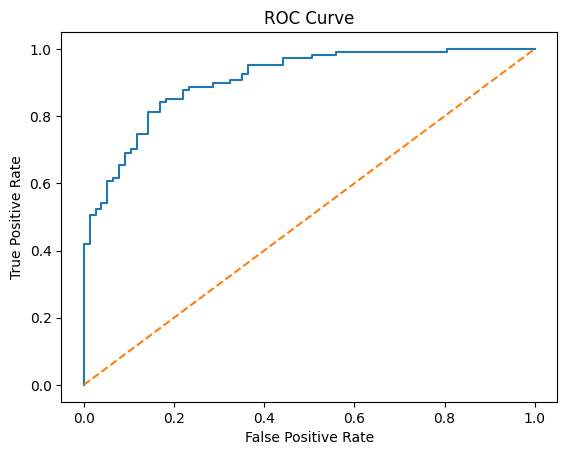

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [15]:
pickle.dump(model, open("model/logistic_model.pkl", "wb"))
pickle.dump(scaler, open("model/scaler.pkl", "wb"))
pickle.dump(selector, open("model/selector.pkl", "wb"))
pickle.dump(X.columns, open("model/all_features.pkl", "wb"))